In [22]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import xgboost as xgb
import joblib

In [2]:
df = pd.read_csv("model_dataset.csv")

df.head()

,city,state,latitude,longitude,datetime,month,day_name,is_weekend,season,time_of_day,...,aqi_lag_1,aqi_lag_3,aqi_lag_6,aqi_lag_12,aqi_lag_24,aqi_roll_mean_24,aqi_roll_max_24,aqi_roll_min_24,aqi_roll_std_24,target_aqi_24h
0,agartala,tripura,23.8315,91.2868,2022-08-06 00:00:00,8.0,saturday,True,monsoon,night,...,55.0,55.0,56.0,55.0,289.0,64.750000,289.0,54.0,47.770511,50.0
1,agartala,tripura,23.8315,91.2868,2022-08-06 01:00:00,8.0,saturday,True,monsoon,night,...,54.0,55.0,55.0,56.0,289.0,54.958333,56.0,54.0,0.750604,50.0
2,agartala,tripura,23.8315,91.2868,2022-08-06 02:00:00,8.0,saturday,True,monsoon,night,...,54.0,55.0,55.0,56.0,54.0,54.958333,56.0,54.0,0.750604,50.0
3,agartala,tripura,23.8315,91.2868,2022-08-06 03:00:00,8.0,saturday,True,monsoon,night,...,54.0,54.0,55.0,56.0,54.0,54.958333,56.0,54.0,0.750604,49.0
4,agartala,tripura,23.8315,91.2868,2022-08-06 04:00:00,8.0,saturday,True,monsoon,night,...,54.0,54.0,55.0,56.0,54.0,54.916667,56.0,53.0,0.829702,49.0


In [3]:
print(df.shape)

(840766, 44)


In [4]:
df["datetime"] = pd.to_datetime(df["datetime"])

In [5]:
df = df.drop(columns=[
    "datetime",
    "us_aqi"
])

In [6]:
categorical_cols = df.select_dtypes(include="object").columns

categorical_cols

Index(['city', 'state', 'day_name', 'season', 'time_of_day', 'aqi_category',
       'pm25_category_india'],
      dtype='object')

In [7]:
label_encoders = {}

for col in categorical_cols:

    encoder = LabelEncoder()

    df[col] = encoder.fit_transform(df[col])

    label_encoders[col] = encoder

In [8]:
df.head()

,city,state,latitude,longitude,month,day_name,is_weekend,season,time_of_day,humidity_percent,...,aqi_lag_1,aqi_lag_3,aqi_lag_6,aqi_lag_12,aqi_lag_24,aqi_roll_mean_24,aqi_roll_max_24,aqi_roll_min_24,aqi_roll_std_24,target_aqi_24h
0,0,25,23.8315,91.2868,8.0,2,True,0,4,93.0,...,55.0,55.0,56.0,55.0,289.0,64.750000,289.0,54.0,47.770511,50.0
1,0,25,23.8315,91.2868,8.0,2,True,0,4,96.0,...,54.0,55.0,55.0,56.0,289.0,54.958333,56.0,54.0,0.750604,50.0
2,0,25,23.8315,91.2868,8.0,2,True,0,4,96.0,...,54.0,55.0,55.0,56.0,54.0,54.958333,56.0,54.0,0.750604,50.0
3,0,25,23.8315,91.2868,8.0,2,True,0,4,96.0,...,54.0,54.0,55.0,56.0,54.0,54.958333,56.0,54.0,0.750604,49.0
4,0,25,23.8315,91.2868,8.0,2,True,0,4,97.0,...,54.0,54.0,55.0,56.0,54.0,54.916667,56.0,53.0,0.829702,49.0


In [9]:
X = df.drop(columns=["target_aqi_24h"])

y = df["target_aqi_24h"]

In [15]:
df_sample = df.sample(n=200000, random_state=42)

print(df_sample.shape)

(200000, 42)


In [16]:
X = df_sample.drop(columns=["target_aqi_24h"])
y = df_sample["target_aqi_24h"]

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(160000, 41)
(40000, 41)


In [18]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=50,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

RandomForestRegressor(max_depth=20, n_estimators=50, n_jobs=-1, random_state=42)

In [19]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

y_pred = rf_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R² :", r2)

MAE : 9.971055877780651
RMSE: 14.491172660371227
R² : 0.9054751808969875


In [20]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
25,aqi_category,0.602317
32,aqi_lag_1,0.216455
17,pm2_5_ugm3,0.052626
18,pm10_ugm3,0.012518
22,o3_ugm3,0.010102
24,aod,0.006306
21,so2_ugm3,0.006128
9,humidity_percent,0.005616
10,dew_point_c,0.005584
15,pressure_msl_hpa,0.005141


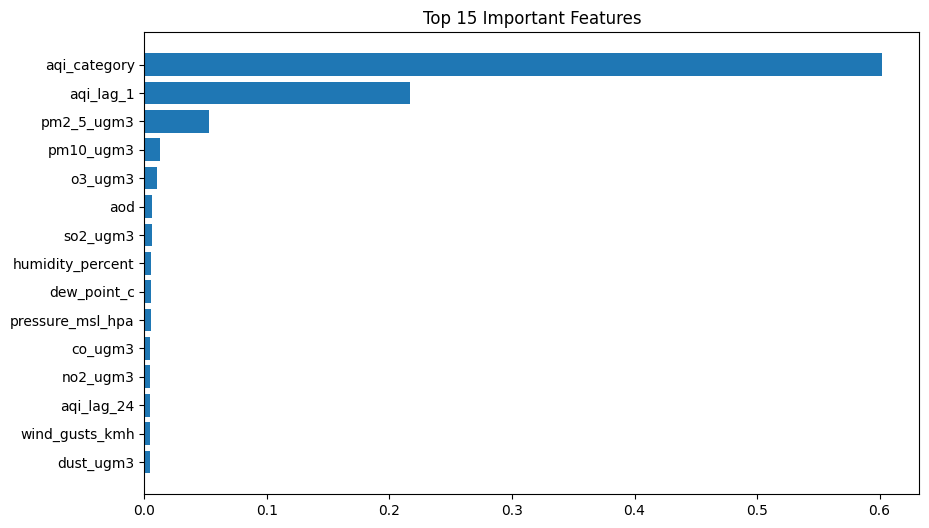

In [23]:
plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"][:15],
    feature_importance["Importance"][:15]
)

plt.gca().invert_yaxis()

plt.title("Top 15 Important Features")

plt.show()

In [24]:
X = df.drop(columns=[
    "target_aqi_24h",
    "aqi_category",
    "pm25_category_india"
])

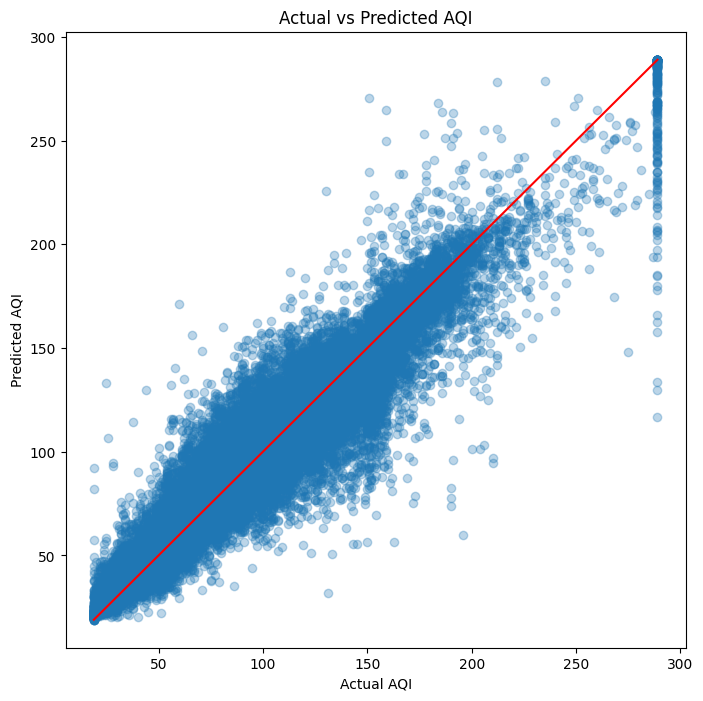

In [25]:
plt.figure(figsize=(8,8))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.3
)

plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")
plt.title("Actual vs Predicted AQI")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)

plt.show()

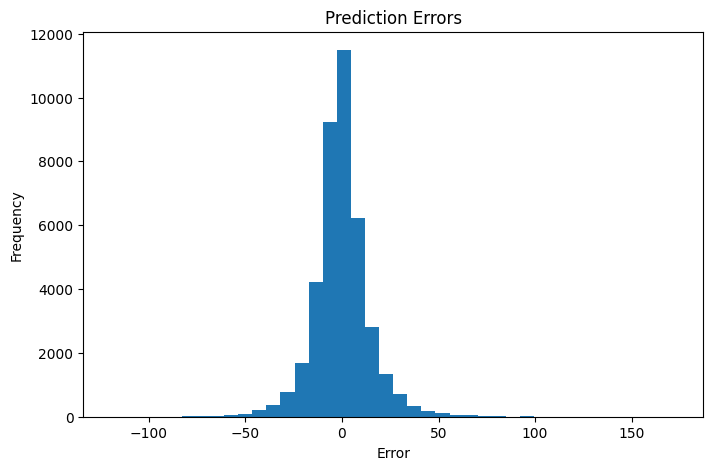

In [26]:
errors = y_test - y_pred

plt.figure(figsize=(8,5))

plt.hist(errors, bins=40)

plt.title("Prediction Errors")
plt.xlabel("Error")
plt.ylabel("Frequency")

plt.show()

# Retraining Model (Without Data Leakage)

In [33]:
df_sample = df.sample(
    n=200000,
    random_state=42
)

print(df_sample.shape)

(200000, 42)


In [34]:
X = df_sample.drop(columns=[
    "target_aqi_24h",
    "aqi_category",
    "pm25_category_india"
])

y = df_sample["target_aqi_24h"]

In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(160000, 39)
(40000, 39)


In [36]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=50,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

RandomForestRegressor(max_depth=20, n_estimators=50, n_jobs=-1, random_state=42)

In [37]:
len(rf_model.estimators_)

50

In [38]:
y_pred = rf_model.predict(X_test)

In [39]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²  : {r2:.4f}")

MAE : 10.01
RMSE: 14.52
R²  : 0.9050


# Retraining Model (Without Data Leakage)

In [ ]:
df_sample = df.sample(
    n=200000,
    random_state=42
)

print(df_sample.shape)

(200000, 42)


In [ ]:
X = df_sample.drop(columns=[
    "target_aqi_24h",
    "aqi_category",
    "pm25_category_india"
])

y = df_sample["target_aqi_24h"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(160000, 39)
(40000, 39)


In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=50,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

RandomForestRegressor(max_depth=20, n_estimators=50, n_jobs=-1, random_state=42)

In [ ]:
len(rf_model.estimators_)

50

In [ ]:
y_pred = rf_model.predict(X_test)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²  : {r2:.4f}")

MAE : 10.01
RMSE: 14.52
R²  : 0.9050


In [45]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
30,aqi_lag_1,0.814916
17,pm2_5_ugm3,0.054202
18,pm10_ugm3,0.013110
22,o3_ugm3,0.011332
24,aod,0.006287
21,so2_ugm3,0.006080
10,dew_point_c,0.005657
9,humidity_percent,0.005399
15,pressure_msl_hpa,0.005177
20,no2_ugm3,0.004991


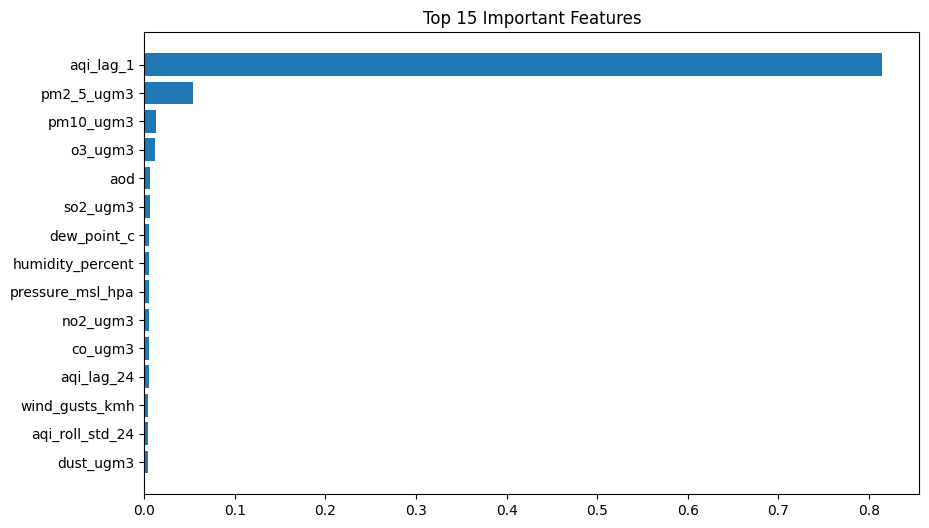

In [41]:
top_features = feature_importance.head(15)

plt.figure(figsize=(10,6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Top 15 Important Features")

plt.show()

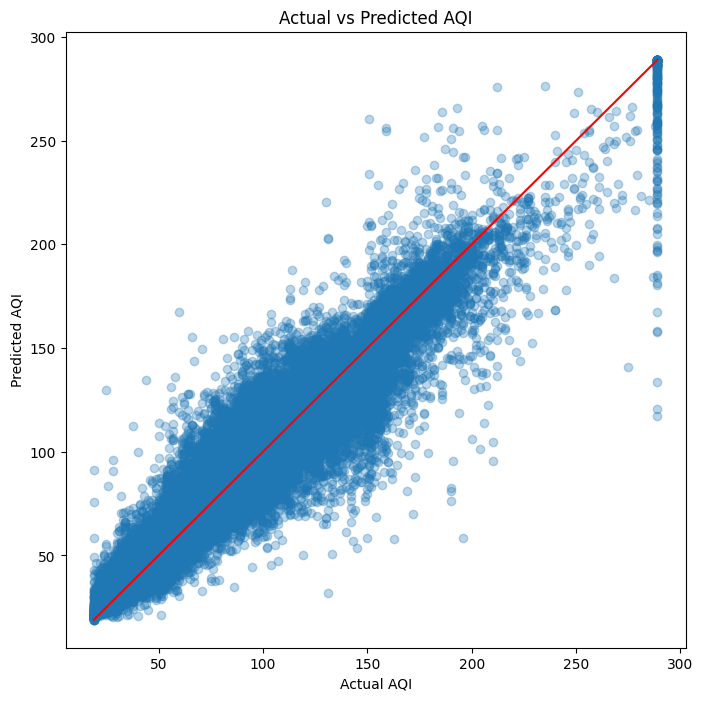

In [42]:
plt.figure(figsize=(8,8))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.3
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)

plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")

plt.title("Actual vs Predicted AQI")

plt.show()

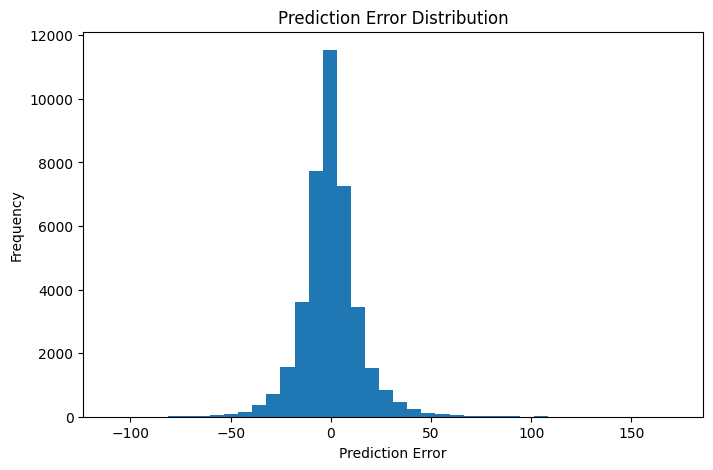

In [43]:
errors = y_test - y_pred

plt.figure(figsize=(8,5))

plt.hist(errors, bins=40)

plt.title("Prediction Error Distribution")

plt.xlabel("Prediction Error")

plt.ylabel("Frequency")

plt.show()

In [46]:
print("="*40)
print("Random Forest Model Summary")
print("="*40)

print(f"Training Samples : {len(X_train)}")
print(f"Testing Samples  : {len(X_test)}")
print(f"Features Used    : {X_train.shape[1]}")
print()
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

Random Forest Model Summary
Training Samples : 160000
Testing Samples  : 40000
Features Used    : 39

MAE  : 10.01
RMSE : 14.52
R²   : 0.9050


In [47]:
import joblib

In [48]:
joblib.dump(rf_model, "aqi_random_forest_model.pkl")

['aqi_random_forest_model.pkl']

In [49]:
joblib.dump(X.columns.tolist(), "model_features.pkl")

['model_features.pkl']

In [50]:
import os

print(os.listdir())

['.config', 'model_features.pkl', 'model_dataset.csv', 'aqi_random_forest_model.pkl', 'sample_data']
